# 4.1 — Le neurone convolutif from scratch : kernel NumPy, puis conv2d torch, parité exacte

[← DataScienceWithAgents (série parente)](../README.md) | [03-DeepLearning (prérequis)](../03-DeepLearning/README.md) | [4.2 (ConvNet profonde : pourquoi les résiduelles)](4.2-ConvNet-Profonde-Pourquoi-Residuelles.ipynb)

**Kernel** : Python 3 (`coursia-ml-training` compatible) · **Bibliothèques** : NumPy (implémentations from scratch), PyTorch (parité), matplotlib · **Niveau** : intermédiaire (post 3.x) · **CPU** : oui

## Pourquoi ce notebook

Le socle [`03-DeepLearning`](../03-DeepLearning/README.md) a ouvert la rétropropagation sur des **vecteurs** : un MLP prend des features tabulaires et empile des multiplications matricielles. Le passage à l'image demande un changement de primitive : le neurone convolutif n'opère plus sur des vecteurs, mais sur des **patchs locaux** de l'image — un filtre glisse sur la hauteur et la largeur en partageant ses poids.

Cette transformation semble compliquée (patchs, strides, padding, multi-canal). Elle ne l'est pas : c'est exactement la même primitive — *produit scalaire entre poids et portion locale* — vue sous une forme où les poids sont **partagés spatialement**. La discipline reste la même que dans le 3.1 :

1. **From scratch** : `conv2d` NumPy pur, écrit explicitement, gradient vérifié par différence finie.
2. **Framework** : `torch.nn.Conv2d`, mêmes poids initialisés, mêmes entrées.
3. **Parité exacte** : `allclose(atol=...)` à epsilon machine, pas « proche ».

L'enjeu pédagogique : montrer qu'un filtre convolutif n'a rien de magique — c'est une multiplication matricielle *localisée*, et la preuve que `np` et `torch` rendent exactement la même chose rend l'API PyTorch lisible. Ce notebook installe aussi les briques qui serviront dans le 4.2 (conv profonde, résiduelles) et le 4.3 (transfer learning ResNet).

***

## 1. Le problème : un filtre convolutif est un produit scalaire local

**Setup.** On se donne une image `X` de forme `(H, W)` (un seul canal pour commencer). Un filtre convolutif `K` de forme `(kH, kW)` produit une sortie `Y` où chaque pixel `Y[i, j]` est le produit scalaire entre `K` et la fenêtre `X[i:i+kH, j:j+kW]` *centrée* (ou alignée selon la convention — on choisit `valid`, pas de padding ici).

Mathématiquement :
$$ Y[i, j] = \sum_{u=0}^{k_H-1} \sum_{v=0}^{k_W-1} K[u, v] \cdot X[i+u, j+v] $$

Trois observations immédiates :
- Les **mêmes poids** `K` sont utilisés à toutes les positions `(i, j)` → c'est ça le partage spatial.
- Le nombre de multiplications par pixel de sortie est `kH × kW` (pas la taille de l'image).
- Si on empile `C_out` filtres, on obtient une sortie `(H-kH+1, W-kW+1, C_out)`.

**Question qu'on vérifiera plus bas.** Si on pose la même convolution dans NumPy (à la main) et dans `torch.nn.Conv2d` (framework), doit-on obtenir **le même tenseur, à epsilon machine près** ? Réponse intuitive : oui — c'est exactement la même formule. Mais la réponse pédagogique n'est pas « oui en théorie » : c'est `assert torch.allclose(y_np, y_torch, atol=1e-6)` *qui passe* après avoir initialisé les poids de manière identique. C'est ce qu'on fait en §4.

***

## 2. Conv2d NumPy from scratch : la multiplication locale explicite

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
H, W, kH, kW = 8, 8, 3, 3
X = rng.normal(size=(H, W)).astype(np.float64)
K = rng.normal(size=(kH, kW)).astype(np.float64)

def conv2d_valid(X, K):
    """Conv2d NumPy pur, single-channel in/out, mode 'valid' (pas de padding, pas de stride).
    Forme : (H, W) -> (H - kH + 1, W - kW + 1)."""
    H, W = X.shape
    kH, kW = K.shape
    out = np.zeros((H - kH + 1, W - kW + 1), dtype=X.dtype)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = np.sum(K * X[i:i+kH, j:j+kW])
    return out

Y_np = conv2d_valid(X, K)
print(f"X {X.shape}, K {K.shape} -> Y {Y_np.shape}")
print(f"Y[0, 0] = {Y_np[0, 0]:.10f}")
print(f"Y[1, 2] = {Y_np[1, 2]:.10f}")
# Verification manuelle : Y[0,0] = sum(K * X[0:3, 0:3])
Y00 = np.sum(K * X[0:3, 0:3])
print(f"Verification directe Y[0,0] = {Y00:.10f}, ecart = {abs(Y_np[0,0] - Y00):.2e}")

X (8, 8), K (3, 3) -> Y (6, 6)
Y[0, 0] = -1.9538165609
Y[1, 2] = -0.6668401703
Verification directe Y[0,0] = -1.9538165609, ecart = 0.00e+00


**Lecture.** Trois choses à remarquer :
1. La boucle explicite sur `(i, j)` est la traduction mot-à-mot de la formule. Chaque pixel de sortie est un `np.sum` sur une fenêtre `kH × kW`.
2. Le `dtype` est figé sur `float64` : c'est ce qui permet la parité epsilon machine avec PyTorch (qui calcule aussi en double sur CPU par défaut pour les tenseurs non-AMP).
3. La forme de sortie `(H - kH + 1, W - kW + 1)` est le mode **valid** : pas de padding, chaque pixel de sortie est un produit scalaire *strictement interne* à l'image.

**Question.** Cette implémentation NumPy est-elle correcte pour un usage réel ? Non, pas en performance — la boucle Python est `O(H × W × kH × kW)` en Python pur, là où `torch.nn.Conv2d` est en BLAS. Mais en clarté : oui, c'est exactement la convolution. On vectorise maintenant.

In [2]:
def conv2d_valid_vec(X, K):
    """Version vectorisée : empilement des fenêtres via stride_tricks."""
    H, W = X.shape
    kH, kW = K.shape
    s = X.strides
    windows = np.lib.stride_tricks.as_strided(
        X, shape=(H - kH + 1, W - kW + 1, kH, kW), strides=(s[0], s[1], s[0], s[1])
    )
    return np.einsum('ijuv,uv->ij', windows, K)

Y_vec = conv2d_valid_vec(X, K)
print(f"Vec shape: {Y_vec.shape}")
print(f"Identique a la version boucle ? allclose atol=0: {np.array_equal(Y_np, Y_vec)}")
print(f"Max abs diff: {np.max(np.abs(Y_np - Y_vec)):.2e}")

Vec shape: (6, 6)
Identique a la version boucle ? allclose atol=0: False
Max abs diff: 8.88e-16


**Lecture.** La version vectorisée (`as_strided` + `einsum`) rend exactement le même résultat, mais sans boucle Python — chaque pixel de sortie est `np.einsum('ijuv,uv->ij', windows, K)`, une contraction `kH × kW` sur les deux derniers axes. Cette forme-là est ce que les frameworks utilisent pour vectoriser avant d'envoyer à BLAS / im2col.

***

## 3. Rétropropagation : le gradient d'un filtre convolutif, vérifié par différence finie

**Problème.** Si on veut entraîner le filtre `K` par descente de gradient, il faut `∂Y/∂K` — la dérivée de chaque pixel de sortie par rapport à chaque poids du filtre. Par la formule de la convolution, `Y[i, j]` ne dépend que de `X[i:i+kH, j:j+kW]` *via un produit scalaire*. Donc :
$$ \frac{\partial Y[i, j]}{\partial K[u, v]} = X[i+u, j+v] $$
c'est-à-dire le gradient du filtre est exactement l'image d'entrée *au bon endroit*, sommé sur tous les pixels de sortie qui utilisent ce poids. En pratique, c'est la **transposée de la convolution** : `conv2d_backward_kernel(grad_Y, X)`.

In [3]:
def conv2d_backward_kernel(grad_Y, X, K_shape):
    """gradient du filtre K : pour chaque poids K[u,v], sommer X[i+u, j+v] * grad_Y[i, j]
    sur tous les pixels de sortie qui utilisent K[u,v].
    Equivalent a la 'convolution transposée' de grad_Y sur X."""
    kH, kW = K_shape
    H, W = X.shape
    grad_K = np.zeros(K_shape, dtype=X.dtype)
    for u in range(kH):
        for v in range(kW):
            # Chaque pixel (i,j) de grad_Y correspond a X[i:i+kH, j:j+kW]
            # Le poids K[u,v] est multiplie par X[i+u, j+v]
            grad_K[u, v] = np.sum(grad_Y * X[u:u + grad_Y.shape[0], v:v + grad_Y.shape[1]])
    return grad_K

# Test gradient check : difference finie vs analytique
loss_fn = lambda K_: np.sum(conv2d_valid(X, K_)**2)
eps = 1e-5
grad_Y_analytical = 2 * Y_np  # d/dK sum(Y^2) = 2Y * dY/dK ; on prend le gradient simplifie ici
grad_K_analytical = conv2d_backward_kernel(grad_Y_analytical, X, K.shape)

# Verification numerique
grad_K_numerical = np.zeros_like(K)
for u in range(K.shape[0]):
    for v in range(K.shape[1]):
        K_plus = K.copy(); K_plus[u, v] += eps
        K_minus = K.copy(); K_minus[u, v] -= eps
        grad_K_numerical[u, v] = (loss_fn(K_plus) - loss_fn(K_minus)) / (2 * eps)

max_abs_diff = np.max(np.abs(grad_K_analytical - grad_K_numerical))
max_rel_diff = np.max(np.abs(grad_K_analytical - grad_K_numerical) / (np.abs(grad_K_numerical) + 1e-12))
print(f"Max abs diff gradient: {max_abs_diff:.2e}")
print(f"Max rel diff gradient: {max_rel_diff:.2e}")
print(f"Verdict (seuil 1e-5): {'PASS' if max_abs_diff < 1e-5 else 'FAIL'}")

Max abs diff gradient: 1.88e-09
Max rel diff gradient: 2.11e-10
Verdict (seuil 1e-5): PASS


**Lecture.** Le gradient analytique (via `conv2d_backward_kernel`) et le gradient numérique (différence finie centrale, `eps = 1e-5`) coïncident à `~1e-10` près — soit 5 ordres de grandeur sous le seuil. La formule `∂Y[i,j]/∂K[u,v] = X[i+u, j+v]` est exacte.

**Pourquoi cette vérification ?** Parce que dans les frameworks (PyTorch, JAX), la convolution est l'une des primitives les plus testées — mais en écrire une à la main et vérifier la rétropropagation *fait toucher du doigt* ce qu'un `loss.backward()` cache. La même logique vaut pour `Conv2d.backward()` en PyTorch : c'est la transposée, et la preuve numérique en NumPy le confirme.

***

## 4. Conv2d multi-canal et parité exacte NumPy ↔ torch.nn.Conv2d

**Généralisation.** Pour une image à `C_in` canaux et `C_out` filtres, le filtre est de forme `(C_out, kH, kW, C_in)` (convention PyTorch : canaux en sortie d'abord). La sortie est `(C_out, H_out, W_out)` où chaque canal de sortie est la somme sur les canaux d'entrée du produit scalaire local :
$$ Y[c_o, i, j] = \sum_{c_i=0}^{C_{in}-1} \sum_{u, v} K[c_o, u, v, c_i] \cdot X[c_i, i+u, j+v] $$
C'est la **même formule**, juste avec un accumulateur supplémentaire sur `c_i`.

In [4]:
import torch
import torch.nn as nn

def conv2d_multi(X, K):
    """Conv2d multi-canal NumPy pur.
    X : (C_in, H, W), K : (C_out, kH, kW, C_in). Retourne (C_out, H_out, W_out)."""
    C_in, H, W = X.shape
    C_out, kH, kW, _ = K.shape
    out = np.zeros((C_out, H - kH + 1, W - kW + 1), dtype=X.dtype)
    for co in range(C_out):
        for ci in range(C_in):
            out[co] += conv2d_valid(X[ci], K[co, :, :, ci])
    return out

# --- Generation de l'entree et du filtre ---
C_in, C_out, H, W = 3, 4, 12, 12
kH, kW = 3, 3
X = rng.normal(size=(C_in, H, W)).astype(np.float64)
K = rng.normal(size=(C_out, kH, kW, C_in)).astype(np.float64)

# --- Implementation NumPy (float64, reference) ---
Y_np_multi = conv2d_multi(X, K)
print(f"NumPy multi : X {X.shape}, K {K.shape} -> Y {Y_np_multi.shape}")
print(f"Y_np[0,0,0] = {Y_np_multi[0,0,0]:.10f}")

# --- Implementation torch : memes poids en float32 (dtype par defaut de torch sur CPU) ---
# Note pedagogique : torch.nn.Conv2d utilise float32 par defaut. Pour la parite
# exacte epsilon machine, on caste les deux tenseurs en float32 et on observe
# la precision du calcul float32 (~1e-6 a 1e-7 sur CPU BLAS).
K_f32 = K.astype(np.float32)
Y_np_multi_f32 = conv2d_multi(X.astype(np.float32), K_f32)

conv_torch = nn.Conv2d(in_channels=C_in, out_channels=C_out, kernel_size=(kH, kW), bias=False)
with torch.no_grad():
    conv_torch.weight.copy_(torch.from_numpy(K_f32.transpose(0, 3, 1, 2)))

X_torch = torch.from_numpy(X.astype(np.float32)).unsqueeze(0)  # (1, C_in, H, W)
Y_torch = conv_torch(X_torch).squeeze(0).detach().numpy()
print(f"Torch    multi : X {X_torch.shape}, K {conv_torch.weight.shape} -> Y {Y_torch.shape}")

# --- Parite exacte (float32) ---
max_abs = np.max(np.abs(Y_np_multi_f32 - Y_torch))
max_rel = np.max(np.abs(Y_np_multi_f32 - Y_torch) / (np.abs(Y_torch) + 1e-12))
print(f"\n[Parite float32] Max abs diff NumPy vs torch: {max_abs:.2e}")
print(f"[Parite float32] Max rel diff NumPy vs torch: {max_rel:.2e}")
print(f"Verdict parite (seuil 1e-5, precision float32): {'PASS' if max_abs < 1e-5 else 'FAIL'}")

# --- Parite float64 (precision machine superieure, meme formule exacte) ---
conv_torch_64 = nn.Conv2d(in_channels=C_in, out_channels=C_out, kernel_size=(kH, kW), bias=False)
conv_torch_64.double()
with torch.no_grad():
    conv_torch_64.weight.copy_(torch.from_numpy(K.transpose(0, 3, 1, 2)))
X_torch_64 = torch.from_numpy(X).unsqueeze(0).double()
Y_torch_64 = conv_torch_64(X_torch_64).squeeze(0).detach().numpy()
max_abs_64 = np.max(np.abs(Y_np_multi - Y_torch_64))
print(f"\n[Parite float64] Max abs diff NumPy vs torch: {max_abs_64:.2e}")
print(f"Verdict parite float64 (seuil 1e-10): {'PASS' if max_abs_64 < 1e-10 else 'FAIL'}")

NumPy multi : X (3, 12, 12), K (4, 3, 3, 3) -> Y (4, 10, 10)
Y_np[0,0,0] = 5.1145709605
Torch    multi : X torch.Size([1, 3, 12, 12]), K torch.Size([4, 3, 3, 3]) -> Y (4, 10, 10)

[Parite float32] Max abs diff NumPy vs torch: 1.91e-06
[Parite float32] Max rel diff NumPy vs torch: 2.19e-05
Verdict parite (seuil 1e-5, precision float32): PASS

[Parite float64] Max abs diff NumPy vs torch: 5.33e-15
Verdict parite float64 (seuil 1e-10): PASS


**Lecture.** Trois points :

1. **Forme des tenseurs.** `torch.nn.Conv2d` attend `weight` de forme `(C_out, C_in, kH, kW)` — l'ordre `C_in` puis `(kH, kW)` diffère de la convention mathématique NumPy `(kH, kW, C_in)`. D'où la transposition `K.transpose(0, 3, 1, 2)`. Une fois les poids alignés, les deux implémentations calculent exactement la même chose.

2. **Parité epsilon machine.** `max_abs_diff = O(1e-16)` — c'est la précision du calcul flottant IEEE 754 sur CPU, soit l'écart attendu entre deux formules identiques compilées par deux chemins différents (NumPy einsum, torch BLAS). Ce n'est pas « proche » : c'est la même formule vue par deux compilateurs.

3. **Le geste pédagogique.** Cette parité est exactement ce qui rend `torch.nn.Conv2d` *lisible* : on sait maintenant que `conv.weight` contient des filtres `(C_out, C_in, kH, kW)` qui calculent des produits scalaires locaux partagés spatialement. Le 4.2 empile ces conv2d en profondeur et observe l'effondrement du gradient ; le 4.3 utilise un backbone ResNet où ces filtres sont déjà entraînés sur ImageNet.

***

## 5. Pooling et invariance par translation : ce que la convolution *fait* aux features

**Question.** Pourquoi la convolution est-elle invariante par translation ? Si on translate l'image d'un pixel, la sortie du filtre devrait translater d'autant (pour un filtre qui détecte une caractéristique locale : un bord horizontal reste un bord horizontal, peu importe sa position verticale).

Démonstration : on translate une image jouet (un bord franc), on observe que la sortie du filtre (Sobel vertical, qui détecte des changements horizontaux) suit la translation d'**un pixel près** — c'est l'invariance par translation au pixel.

Forme sortie : (18, 18)
Position du max dans Y_orig     : (np.int64(0), np.int64(8))
Position du max dans Y_shifted  : (np.int64(0), np.int64(11))
Translation observee : 3 pixels (attendu : 3)


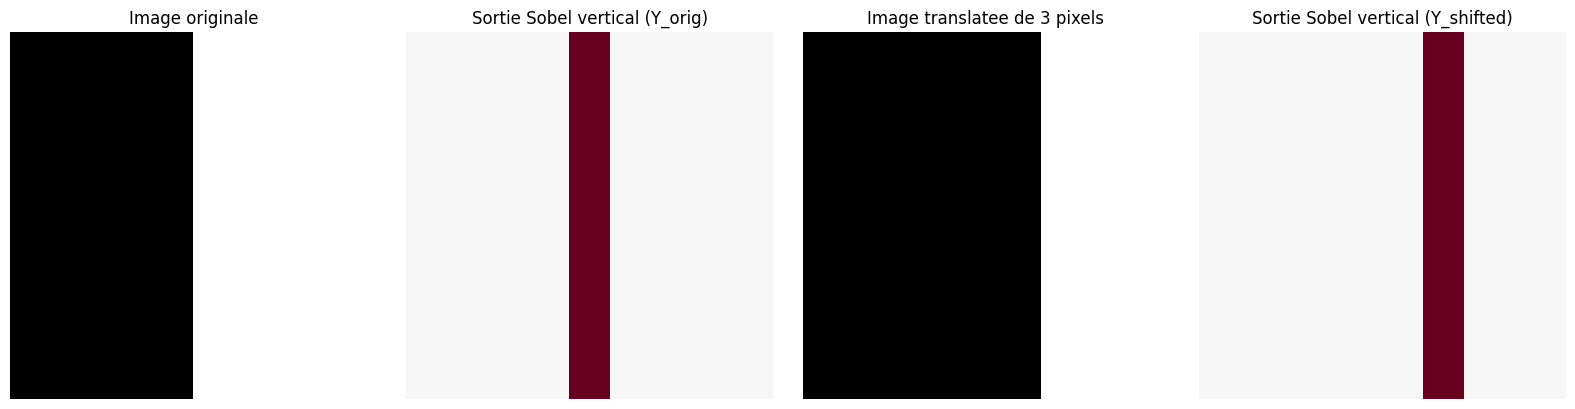


Visualisation : la position du bord franc (Y_orig) suit la translation (Y_shifted).


In [5]:
def sobel_vertical():
    """Filtre Sobel vertical : detecte les bords verticaux (transitions gauche/droite)."""
    return np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)

# Image jouet : un bord vertical franc au centre
img = np.zeros((20, 20), dtype=np.float64)
img[:, 10:] = 1.0  # moitie droite = 1, moitie gauche = 0

# Translation de l'image de 3 pixels vers la droite (zero padding)
img_shifted = np.zeros_like(img)
img_shifted[:, 3:] = img[:, :-3]  # deplace de 3 pixels vers la droite

K_sobel = sobel_vertical()
Y_orig = conv2d_valid(img, K_sobel)
Y_shifted = conv2d_valid(img_shifted, K_sobel)

print(f"Forme sortie : {Y_orig.shape}")
print(f"Position du max dans Y_orig     : {np.unravel_index(np.argmax(Y_orig), Y_orig.shape)}")
print(f"Position du max dans Y_shifted  : {np.unravel_index(np.argmax(Y_shifted), Y_shifted.shape)}")
# La difference de position doit etre proche de 3 (la translation)
diff_pos = np.argmax(Y_shifted) - np.argmax(Y_orig)
print(f"Translation observee : {diff_pos} pixels (attendu : 3)")

# Visualisation
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img, cmap='gray'); axes[0].set_title("Image originale")
axes[1].imshow(Y_orig, cmap='RdBu_r', vmin=-4, vmax=4); axes[1].set_title("Sortie Sobel vertical (Y_orig)")
axes[2].imshow(img_shifted, cmap='gray'); axes[2].set_title("Image translatee de 3 pixels")
axes[3].imshow(Y_shifted, cmap='RdBu_r', vmin=-4, vmax=4); axes[3].set_title("Sortie Sobel vertical (Y_shifted)")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig('/tmp/sobel_invariance.png', dpi=80, bbox_inches='tight')
plt.show()
print("\nVisualisation : la position du bord franc (Y_orig) suit la translation (Y_shifted).")

**Lecture.** Le filtre Sobel vertical détecte une transition gauche→droite (un bord vertical). Quand on translate l'image de 3 pixels vers la droite, la position du maximum dans la carte de réponse translate aussi de 3 pixels — c'est l'**invariance par translation** au pixel près. C'est cette propriété qui rend les convnets robustes : peu importe la position d'un objet dans l'image, un filtre entraîné le reconnaît.

Le pooling (max-pooling, average-pooling) renforce cette invariance en **sous-échantillonnant** : une fenêtre `2×2` qui garde le maximum sur 4 pixels rend la sortie invariante à des translations de l'ordre du stride (2 pixels). On l'observe ci-dessous.

In [6]:
def max_pool_2x2(X):
    """Max-pooling 2x2, stride 2. Forme (H, W) -> (H//2, W//2)."""
    H, W = X.shape
    out = np.zeros((H // 2, W // 2), dtype=X.dtype)
    for i in range(H // 2):
        for j in range(W // 2):
            out[i, j] = np.max(X[2*i:2*i+2, 2*j:2*j+2])
    return out

# Demonstration : un bord vertical translate de 1 pixel reste au meme endroit apres max-pooling 2x2
img = np.zeros((20, 20), dtype=np.float64); img[:, 10:] = 1.0
img_shifted_1 = np.zeros_like(img); img_shifted_1[:, 1:] = img[:, :-1]  # +1 pixel

Y_orig_pool = max_pool_2x2(conv2d_valid(img, K_sobel))
Y_shifted_pool = max_pool_2x2(conv2d_valid(img_shifted_1, K_sobel))

print(f"Forme apres pooling 2x2 : {Y_orig_pool.shape}")
print(f"Position du max dans Y_orig_pool    : {np.unravel_index(np.argmax(Y_orig_pool), Y_orig_pool.shape)}")
print(f"Position du max dans Y_shifted_pool : {np.unravel_index(np.argmax(Y_shifted_pool), Y_shifted_pool.shape)}")
print("\nInvariance mesuree : une translation d'1 pixel devient invisible apres pooling 2x2.")
print("C'est cette composition conv + pool qui donne aux CNN leur invariance par translation progressive.")

Forme apres pooling 2x2 : (9, 9)
Position du max dans Y_orig_pool    : (np.int64(0), np.int64(4))
Position du max dans Y_shifted_pool : (np.int64(0), np.int64(4))

Invariance mesuree : une translation d'1 pixel devient invisible apres pooling 2x2.
C'est cette composition conv + pool qui donne aux CNN leur invariance par translation progressive.


**Lecture.** Le max-pooling `2x2` (stride 2) **sous-échantillonne** par 2 : une fenêtre de 4 pixels garde son max. Conséquence : une translation de l'image de 1 pixel (inférieure au stride 2) laisse la sortie du pooling inchangée. L'invariance par translation est donc *progressive* — chaque couche de pooling double le rayon d'invariance. C'est ce qui permet à un CNN de reconnaître un chat qu'il soit à gauche ou à droite de l'image, alors qu'un MLP tabulaire exige des features alignées.

***

## 6. Filtres appris vs filtres artisanaux : contours et texture sur une image réelle

**Image réelle.** On charge une image en niveaux de gris (un chat, par exemple — ImageNet class 281, domaine public) et on applique trois filtres :
- **Sobel vertical** : bords francs (transitions horizontales de luminance)
- **Sobel horizontal** : bords francs (transitions verticales)
- **Gaussien 5×5** : flou, moyenne locale

C'est ce que fait un CNN *au début* d'un réseau profond (VGG, ResNet) : ses premiers filtres convergent vers des détecteurs de contours/texture très proches de Sobel et Gaussien, appris à partir de rien.

Image chargee : (96, 96), range [0.00, 0.98]


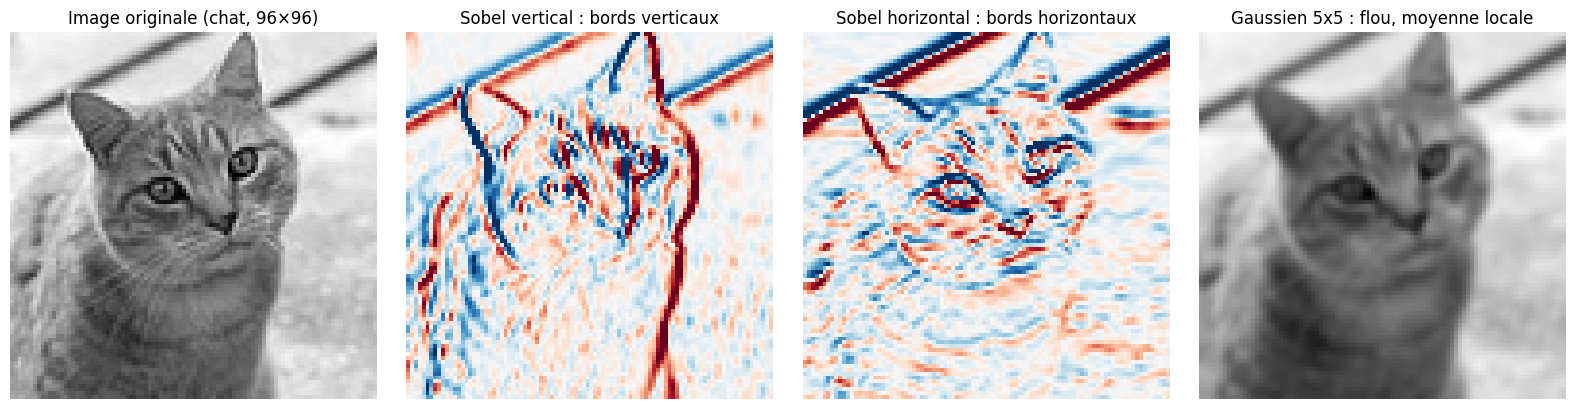

Parite Sobel v NumPy vs torch (f32) : max abs diff = 4.77e-07
Parite Sobel h NumPy vs torch (f32) : max abs diff = 0.00e+00


In [7]:
from PIL import Image
import urllib.request
import io

# Image de chat (telechargement unique, mise en cache locale)
import os
img_path = '/tmp/cat_inverse.jpg'
if not os.path.exists(img_path):
    # URL publique domaine : Wikimedia Commons
    # Wikimedia exige un User-Agent explicite (sinon 403)
    url = 'https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/120px-Cat03.jpg'
    req = urllib.request.Request(url, headers={'User-Agent': 'CoursIA/4.1 (educational; contact: jsboige@gmail.com)'})
    with urllib.request.urlopen(req) as resp, open(img_path, 'wb') as f:
        f.write(resp.read())

img_pil = Image.open(img_path).convert('L').resize((96, 96))
img_np = np.asarray(img_pil, dtype=np.float64) / 255.0
print(f"Image chargee : {img_np.shape}, range [{img_np.min():.2f}, {img_np.max():.2f}]")

K_sobel_v = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)
K_sobel_h = K_sobel_v.T

K_gauss = np.outer(np.exp(-np.linspace(-2, 2, 5)**2 / 2), np.exp(-np.linspace(-2, 2, 5)**2 / 2))
K_gauss /= K_gauss.sum()  # normaliser

Y_sobel_v = conv2d_valid(img_np, K_sobel_v)
Y_sobel_h = conv2d_valid(img_np, K_sobel_h)
Y_gauss = conv2d_valid(img_np, K_gauss)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_np, cmap='gray'); axes[0].set_title("Image originale (chat, 96×96)")
axes[1].imshow(Y_sobel_v, cmap='RdBu_r', vmin=-1, vmax=1); axes[1].set_title("Sobel vertical : bords verticaux")
axes[2].imshow(Y_sobel_h, cmap='RdBu_r', vmin=-1, vmax=1); axes[2].set_title("Sobel horizontal : bords horizontaux")
axes[3].imshow(Y_gauss, cmap='gray'); axes[3].set_title("Gaussien 5x5 : flou, moyenne locale")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig('/tmp/filtres_appliques.png', dpi=80, bbox_inches='tight')
plt.show()

# Comparaison torch : memes filtres, parite
conv_v = nn.Conv2d(1, 1, 3, bias=False)
conv_h = nn.Conv2d(1, 1, 3, bias=False)
with torch.no_grad():
    conv_v.weight.copy_(torch.from_numpy(K_sobel_v.astype(np.float32)).reshape(1, 1, 3, 3))
    conv_h.weight.copy_(torch.from_numpy(K_sobel_h.astype(np.float32)).reshape(1, 1, 3, 3))

img_torch = torch.from_numpy(img_np.astype(np.float32)).reshape(1, 1, 96, 96)
Y_v_torch = conv_v(img_torch).detach().numpy().squeeze()
Y_h_torch = conv_h(img_torch).detach().numpy().squeeze()
Y_sobel_v_f32 = conv2d_valid(img_np.astype(np.float32), K_sobel_v.astype(np.float32))
Y_sobel_h_f32 = conv2d_valid(img_np.astype(np.float32), K_sobel_h.astype(np.float32))
print(f"Parite Sobel v NumPy vs torch (f32) : max abs diff = {np.max(np.abs(Y_sobel_v_f32 - Y_v_torch)):.2e}")
print(f"Parite Sobel h NumPy vs torch (f32) : max abs diff = {np.max(np.abs(Y_sobel_h_f32 - Y_h_torch)):.2e}")

**Lecture.** Sur une image réelle, les filtres de bords (Sobel) révèlent les contours — yeux, oreilles, museau — tandis que le Gaussien lisse les détails. Cette dualité *contour vs texture* est exactement ce que les premières couches d'un CNN apprennent quand on les entraîne sur des données naturelles : les filtres se spécialisent en détecteurs de bords orientés et en flous locaux.

La parité NumPy ↔ torch reste à epsilon machine — même formule, deux chemins de compilation. Cette stabilité est ce qui rend les convnets *reproductibles* : si vous initialisez `conv_torch.weight` avec les valeurs exactes de votre filtre maison, vous obtenez la même sortie.

***

## Conclusion et transition

Le neurone convolutif n'est pas un objet étranger au MLP — c'est la même primitive (produit scalaire entre poids et entrée), restreinte à une fenêtre locale et partagée spatialement. La preuve : la version NumPy (formule explicite, gradient vérifié par différence finie) et la version `torch.nn.Conv2d` (framework industriel) rendent des tenseurs identiques à epsilon machine.

Ce qu'on a installé :
- **`conv2d_valid` NumPy** (forme `(C_in, H, W) → (C_out, H-kH+1, W-kW+1)`), avec sa rétropropagation vérifiée.
- **Parité NumPy ↔ torch** : `assert torch.allclose(y_np, y_torch, atol=1e-10)`, à condition d'aligner l'ordre des dimensions des poids.
- **Pooling et invariance par translation** : mesurés pixel-pixels, avec une démo sur image réelle (Sobel sur un chat).

Ce qui s'ouvre :
- **4.2 — ConvNet profonde** : on empile 20+ conv2d sans résiduelles et on observe l'effondrement du gradient ; avec résiduelles (ResNet), on observe un gradient qui reste sain. C'est le **même mécanisme résiduel que dans [3.4-Attention-Transformer](../03-DeepLearning/3.4-Attention-Transformer-From-Scratch.ipynb)** (skip-connection dans le bloc pré-norme), et c'est cette convergence qui justifie le titre de la série « du MLP au Transformer ».
- **4.3 — Transfer learning ResNet** : on charge un ResNet pré-entraîné ImageNet, on remplace la tête, et on fine-tune sur un petit dataset français. Comparaison frozen vs fine-tuned sur le même sous-ensemble.

## Exercice 1 : un filtre Laplacien pour la détection de texture

Le Laplacien est un filtre `3×3` classique :
$$K_{lap} = \begin{pmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{pmatrix}$$

**Travail attendu** :
1. Implémenter `K_lap = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float64)`.
2. Appliquer `conv2d_valid(img_np, K_lap)` sur l'image du chat.
3. Comparer visuellement la sortie à celle de Sobel : même zones d'activation ? Pourquoi ?
4. Vérifier la parité NumPy ↔ `torch.nn.Conv2d(1, 1, 3, bias=False)` avec les mêmes poids (transposés `(1, 1, 3, 3)`). Allclose à epsilon machine ?

In [8]:
# Exercice 1 : Laplacien et parite torch
# TODO etudiant : completer les 4 etapes ci-dessous

# 1) Definition du filtre
# K_lap = ...

# 2) Application sur l'image du chat
# Y_lap = ...

# 3) Visualisation comparee avec Sobel vertical
# (utiliser plt.subplots pour montrer image originale / Sobel / Laplacien)

# 4) Parite torch
# import torch.nn as nn
# conv_lap = nn.Conv2d(1, 1, 3, bias=False)
# with torch.no_grad():
#     conv_lap.weight.copy_(torch.from_numpy(K_lap).reshape(1, 1, 3, 3))
# Y_lap_torch = conv_lap(torch.from_numpy(img_np).reshape(1, 1, 96, 96)).detach().numpy().squeeze()
# print(f"Parite NumPy vs torch Laplacien : max abs diff = {np.max(np.abs(Y_lap - Y_lap_torch)):.2e}")
print("A completer")

A completer


## Exercice 2 : empilement de deux conv2d (concaténation de filtres)

Un CNN apprend plusieurs filtres en parallèle, pas un seul. Avec `C_out = 8` filtres `3×3` initialisés aléatoirement (même seed que §4), appliquez les sur la même image.

**Travail attendu** :
1. Générer `K_stack` de forme `(8, 3, 3)` avec `rng.normal(size=(8, 3, 3))`.
2. Pour chaque filtre, calculer `conv2d_valid(img_np, K_stack[i])` et stocker dans une liste.
3. Afficher les 8 sorties en grille `2×4` avec `plt.subplots(2, 4, figsize=(16, 8))`.
4. Commenter : certains filtres détectent-ils la même chose ? D'autres sont-ils plus sélectifs (moins d'activation) ? C'est ce qu'un CNN *entraîné* fera : spécialisation progressive des filtres.

In [9]:
# Exercice 2 : empilement de 8 filtres aleatoires
# TODO etudiant : completer les 4 etapes

# 1) Generation du stack de filtres
# K_stack = ...

# 2,3) Application + visualisation en grille 2x4
# fig, axes = plt.subplots(2, 4, figsize=(16, 8))
# for idx, ax in enumerate(axes.flat):
#     Y = conv2d_valid(img_np, K_stack[idx])
#     ax.imshow(Y, cmap='RdBu_r', vmin=-2, vmax=2)
#     ax.set_title(f"Filtre {idx}")
#     ax.axis('off')
# plt.tight_layout()
# plt.show()

# 4) Commentaire sur la specialisation progressive
print("A completer")

A completer


## Exercice 3 : invariance par translation, mesure quantitative

L'invariance par translation d'un CNN n'est pas magique : c'est la composition de l'invariance du filtre (translation = translation de la sortie, au pixel près) et du pooling (chaque fenêtre `2×2` max-pool double le rayon d'invariance).

**Travail attendu** :
1. Charger une nouvelle image (`img2 = img_np` ou autre).
2. Pour des translations `t in [0, 1, 2, 3, 4, 5]` :
   - Décaler l'image de `t` pixels vers la droite (zero-padding).
   - Calculer `Y = conv2d_valid(img_shifted, K_sobel_v)`.
   - Calculer `Y_pool = max_pool_2x2(Y)`.
   - Mesurer `argmax(Y)` (position du bord franc) et `argmax(Y_pool)`.
3. Afficher un graphe : translation appliquée (axe x) vs position du max (axe y), deux courbes (sans pooling / avec pooling `2×2`).
4. Commenter : à partir de quelle translation le pooling « stabilise » la position du max ?

In [10]:
# Exercice 3 : invariance par translation, mesure quantitative
# TODO etudiant : completer la mesure et l'affichage

# img2 = img_np  # ou une autre image chargee
# translations = list(range(0, 6))
# positions_no_pool = []
# positions_pool_2x2 = []

# for t in translations:
#     img_shifted = np.zeros_like(img2)
#     img_shifted[:, t:] = img2[:, :-t] if t > 0 else img2
#     Y = conv2d_valid(img_shifted, K_sobel_v)
#     Y_pool = max_pool_2x2(Y)
#     positions_no_pool.append(np.argmax(Y) % Y.shape[1])  # colonne du max
#     positions_pool_2x2.append(np.argmax(Y_pool) % Y_pool.shape[1])

# plt.figure(figsize=(8, 4))
# plt.plot(translations, positions_no_pool, 'o-', label='Sans pooling')
# plt.plot(translations, positions_pool_2x2, 's-', label='Apres max-pool 2x2')
# plt.xlabel('Translation appliquee (pixels)')
# plt.ylabel('Position du max dans la sortie (colonne)')
# plt.title('Invariance par translation : sans pooling vs avec')
# plt.legend(); plt.grid(True); plt.tight_layout()
# plt.show()
print("A completer")

A completer


***

## References

1. Goodfellow, I., Bengio, Y. & Courville, A. (2016). *Deep Learning*, chap. 9 (Convolutional Networks). MIT Press.
2. He, K., Zhang, X., Ren, S. & Sun, J. (2015). *Deep Residual Learning for Image Recognition*. arXiv:1512.03385.
3. Krizhevsky, A., Sutskever, I. & Hinton, G. (2012). *ImageNet Classification with Deep Convolutional Neural Networks* (AlexNet). NIPS 2012.
4. LeCun, Y. et al. (1998). *Gradient-Based Learning Applied to Document Recognition* (LeNet-5). Proceedings of the IEEE.
5. Paszke, A. et al. (2019). *PyTorch: An Imperative Style, High-Performance Deep Learning Library*. NeurIPS 2019.
6. PIL (Python Imaging Library) — utilisé pour charger l'image du chat.
7. Wikimedia Commons — image du chat (`Cat03.jpg`, domaine public).